In [9]:
import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch import nn

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Create Wine Dataset Class

In [162]:
class WineDataset(Dataset):
    def __init__(self):
        # load data
        df = pd.read_csv('data/raw/wine.csv')
        self.n_samples = len(df)

        self.x_data = torch.from_numpy(df.drop('Wine', axis=1).values).type(torch.float32)
        self.y_data = torch.from_numpy(df['Wine'].values).type(torch.LongTensor) - 1 # subtract 1 to start at 0

    def __len__(self):
        return self.n_samples
    
    def __getitem__(self,index):
        return self.x_data[index], self.y_data[index]

In [163]:
wine_data = WineDataset()
wine_data

In [179]:
whole_datasetloader = DataLoader(wine_data, batch_size = 20, shuffle=True)
whole_datasetloader

Split into train, validation, and test datasets.

In [177]:
train_proportion = 0.7
val_proportion = 0.15

train_size = int(train_proportion*len(wine_data))
val_size = int(val_proportion*len(wine_data))
test_size = len(wine_data) - train_size - val_size

generator1 = torch.Generator().manual_seed(42)

from torch.utils.data import random_split

train_data, val_data, test_data = random_split(wine_data, [train_size, val_size, test_size])

In [180]:
train_loader = DataLoader(train_data, batch_size=20, shuffle=True)
val_loader = DataLoader(val_data, batch_size = len(val_data), shuffle=True)
test_loader = DataLoader(test_data, batch_size = len(test_data), shuffle=True)

Create Neural Network

In [188]:
model = nn.Sequential(
    nn.Linear(13, 16), # 13 features in wine datasets
    nn.ReLU(),
    nn.Linear(16,3), # 3 altearnative categories. Can add softmax function at the end to normalize and get scores in probabilities
)

Train the network

In [ ]:
nepochs = 200

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_function = nn.CrossEntropyLoss()

train_losses = []
model.train()
for epoch in range(nepochs):

    train_batch_losses = []
    for ibatch, (features, labels) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(features)

        loss = loss_function(output, labels)
        train_batch_losses.append(loss.item())

        loss.backward()

        optimizer.step()

    train_losses.append(np.mean(train_batch_losses))

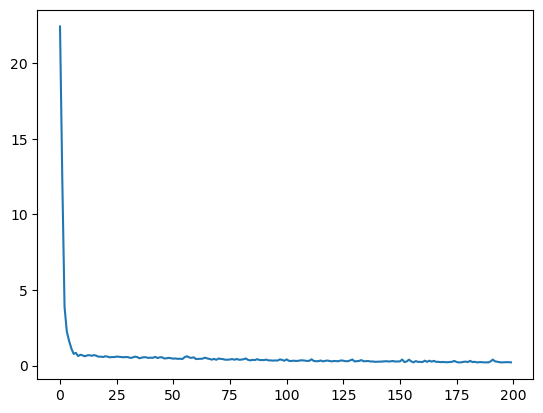

In [195]:
plt.plot(train_losses)

In [196]:
((torch.argmax(output, dim=1)) == labels).sum() / len(labels)

tensor(1.)

Test

In [199]:
test_features, test_labels = next(iter(test_loader))

output = model(test_features)

pred_labels = torch.argmax(output, dim=1)

test_accuracy = (pred_labels == test_labels).sum()/len(test_labels)
test_accuracy

tensor(0.9286)